# Content-based, Naive Bayes and hybrid recommenders

Collaborative filtering has a blind spot: a movie that nobody has rated yet cannot be recommended, because the method knows nothing about it except its ratings. This is the **cold-start problem**, and it affects every new item in a catalogue.

**Content-based** recommenders use what we know about the items themselves (here genres and release decade) and match it to a profile of what each user liked. This notebook:

1. builds item feature vectors and **user profiles**, and measures how well they separate liked from disliked movies, including movies that never appeared in the training data;
2. trains a per-user **Naive Bayes** classifier that predicts "like" vs "dislike" from the features of a movie;
3. combines content with item-based collaborative filtering in a **hybrid** recommender and evaluates it on top-N recommendation, where new movies are part of the catalogue.

We use the same MovieLens data and the same temporal split as in the collaborative filtering notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import normalize

plt.rcParams["figure.dpi"] = 100

ratings = pd.read_csv("data/movielens/ratings.csv").sort_values("timestamp")
movies = pd.read_csv("data/movielens/movies.csv")
tags = pd.read_csv("data/movielens/tags.csv")

position = ratings.groupby("userId").cumcount(ascending=False)
is_test = position < (0.2 * ratings.groupby("userId")["userId"].transform("size")).round()
train, test = ratings[~is_test].copy(), ratings[is_test].copy()

item_index = {m: i for i, m in enumerate(movies["movieId"])}
for df in (train, test):
    df["i"] = df["movieId"].map(item_index)
test["new"] = ~test["movieId"].isin(train["movieId"])
print(f"test ratings: {len(test):,}, of which {test['new'].sum():,} on movies never rated in the training period "
      f"({test.loc[test['new'], 'movieId'].nunique():,} movies)")

test ratings: 20,164, of which 1,693 on movies never rated in the training period (1,486 movies)


About 8% of the test ratings (1,693) concern **1,486 movies that nobody had rated during the training period**. For collaborative filtering these movies do not exist.

## 1. Item features and user profiles

Each movie is described by its **genres** and its **release decade**, turned into a TF-IDF vector: rare genres (Film-Noir, Western) weigh more than common ones (Drama, Comedy), which carry less information about taste.

In [2]:
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)\s*$").astype(float)
movies["decade"] = "decade" + (movies["year"] // 10 * 10).fillna(0).astype(int).astype(str)

def item_features(extra_text=None):
    text = movies["genres"].str.replace("|", " ").str.replace("-", "") + " " + movies["decade"]
    if extra_text is not None:
        text = text + " " + movies["movieId"].map(extra_text).fillna("")
    vectorizer = TfidfVectorizer(token_pattern=r"[a-z0-9]+", min_df=2)
    return normalize(vectorizer.fit_transform(text.str.lower())), vectorizer

X, vectorizer = item_features()
print(f"{X.shape[0]:,} movies x {X.shape[1]} features:", ", ".join(vectorizer.get_feature_names_out()[:12]), "...")

9,742 movies x 35 features: action, adventure, animation, children, comedy, crime, decade0, decade1900, decade1910, decade1920, decade1930, decade1940 ...


A user's **profile** is the weighted sum of the vectors of the movies they rated, with weight $r_{ui} - \bar r_u$: movies rated above the user's average pull the profile towards their features, movies rated below push it away. A movie's score is the cosine between its vector and the profile.

In [3]:
def user_profiles(X, ratings):
    centred = ratings["rating"] - ratings.groupby("userId")["rating"].transform("mean")
    profiles = {}
    for u, rows in ratings.assign(w=centred).groupby("userId"):
        profiles[u] = normalize(np.asarray(X[rows["i"].to_numpy()].T @ rows["w"].to_numpy()).reshape(1, -1))[0]
    return profiles

def content_scores(X, profiles, df):
    return np.array([X[i] @ profiles[u] for u, i in zip(df["userId"], df["i"])]).ravel()

profiles = user_profiles(X, train)
test["content"] = content_scores(X, profiles, test)
liked = test["rating"] >= 4
auc = pd.Series({
    "all test ratings": roc_auc_score(liked, test["content"]),
    "movies already rated in training": roc_auc_score(liked[~test["new"]], test.loc[~test["new"], "content"]),
    "new movies (cold start)": roc_auc_score(liked[test["new"]], test.loc[test["new"], "content"]),
}, name="AUC liked vs not liked")
auc.round(3)

all test ratings                    0.627
movies already rated in training    0.625
new movies (cold start)             0.649
Name: AUC liked vs not liked, dtype: float64

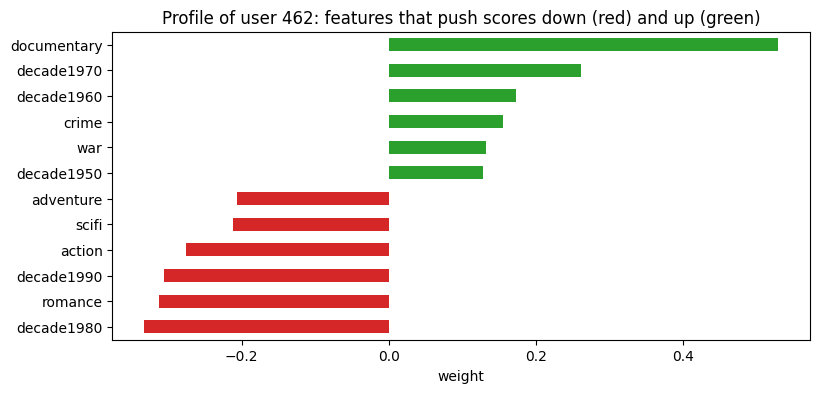

In [4]:
names = vectorizer.get_feature_names_out()
u_example = train["userId"].value_counts().index[50]
p = pd.Series(profiles[u_example], index=names).sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
pd.concat([p.head(6), p.tail(6)]).plot.barh(ax=ax, color=["tab:red"] * 6 + ["tab:green"] * 6)
ax.set(title=f"Profile of user {u_example}: features that push scores down (red) and up (green)", xlabel="weight")
plt.show()

The AUC is the probability that a randomly chosen liked movie gets a higher score than a randomly chosen disliked one (0.5 is chance). With only 35 features, genres and decade, the content profile reaches an AUC of about **0.63**, clearly better than chance but far from a precise predictor: genres say *what kind* of movie it is, not whether it is good. Importantly, it works at least as well on **new movies** (0.65) as on known ones. Content does not need anybody to have rated a movie.

The example profile shows how the method reads a user: positive weights on the genres and decades they rate above their own average, negative weights on the ones they rate below.

### Why not use the tags?

MovieLens also contains free-text **tags** that users attached to movies ("dark comedy", "time travel", "Pixar"). They are rich content, and adding them raises the AUC:

In [5]:
tag_text = tags.groupby("movieId")["tag"].apply(lambda s: " ".join(s.str.lower()))
X_tags, _ = item_features(tag_text)
with_tags = content_scores(X_tags, user_profiles(X_tags, train), test)
pd.Series({"genres + decade": roc_auc_score(liked, test["content"]),
           "genres + decade + all tags": roc_auc_score(liked, with_tags)}, name="AUC").round(3)

genres + decade               0.627
genres + decade + all tags    0.664
Name: AUC, dtype: float64

But the comparison is not fair. Tags are written by users **after** watching a movie, often at the same moment they rate it. Using all tags lets the model see information produced in the test period, including by the very user we are predicting for: a tag on a movie reveals that someone watched it. This is **data leakage**, and it would inflate any evaluation. A deployed system could only use the tags that existed at prediction time, so we keep the leak-free features.

## 2. A per-user Naive Bayes classifier

Instead of a similarity score, we can treat recommendation as **classification**: for each user, learn from their own history whether a movie with given features is liked (rating ≥ 4) or not. A **Bernoulli Naive Bayes** model assumes features are independent given the class:

$$P(\text{like} \mid x) \propto P(\text{like}) \prod_j P(x_j \mid \text{like}),$$

which needs very little data per user, a good property when each user has a few dozen ratings.

In [6]:
binary = (X > 0).astype(np.int8)
nb_scores = np.full(len(test), np.nan)
for u, rows in train.groupby("userId"):
    y = (rows["rating"] >= 4).to_numpy()
    mask = (test["userId"] == u).to_numpy()
    if y.all() or not y.any() or not mask.any():
        continue
    model = BernoulliNB(alpha=1.0).fit(binary[rows["i"].to_numpy()], y)
    nb_scores[mask] = model.predict_proba(binary[test.loc[mask, "i"].to_numpy()])[:, 1]
test["naive_bayes"] = nb_scores

ok = test["naive_bayes"].notna()
train_like_rate = train.groupby("userId")["rating"].apply(lambda s: (s >= 4).mean())
majority_pred = test.loc[ok, "userId"].map(train_like_rate) >= 0.5
pd.DataFrame({
    "Naive Bayes (per user)": {"AUC": roc_auc_score(liked[ok], test.loc[ok, "naive_bayes"]),
                               "accuracy": ((test.loc[ok, "naive_bayes"] >= 0.5) == liked[ok]).mean()},
    "content profile (cosine)": {"AUC": roc_auc_score(liked[ok], test.loc[ok, "content"]), "accuracy": np.nan},
    "majority class of each user": {"AUC": 0.5, "accuracy": (majority_pred == liked[ok]).mean()},
}).T.round(3)

,AUC,accuracy
Naive Bayes (per user),0.731,0.666
content profile (cosine),0.627,NaN
majority class of each user,0.500,0.649


On the same test ratings, the per-user Naive Bayes classifier ranks liked movies much better than the cosine profile (AUC **0.73** vs 0.63). The probabilistic model uses each user's own base rate of liking movies and weighs every feature by how informative it is *for that user*. As a hard classifier, however, its accuracy (67%) is only slightly above always predicting each user's most frequent class (65%): most users like most of what they watch, and the hard part is spotting the exceptions.

## 3. A hybrid recommender

Item-based collaborative filtering captures *who watched what* and is strong for movies with many ratings; content scores work for every movie, including new ones. A simple **weighted hybrid** combines them. Both scores are first converted into ranks within each user's candidate list (so that their scales do not matter), then mixed:

$$\text{score} = \alpha \cdot \text{rank}_{\text{CF}} + (1 - \alpha) \cdot \text{rank}_{\text{content}} .$$

We evaluate top-10 recommendations over the **whole catalogue**, new movies included, with the same metrics as before.

In [7]:
n_items = len(movies)
seen = np.zeros((train["userId"].max() + 1, n_items), bool)
seen[train["userId"], train["i"]] = True
known = np.zeros(n_items, bool)
known[train["i"].unique()] = True

# item-based CF: centred cosine between items over the training ratings, as in the previous notebook
R = np.zeros((train["userId"].max() + 1, n_items), np.float32)
R[train["userId"], train["i"]] = train["rating"] - train.groupby("userId")["rating"].transform("mean")
norms = np.sqrt((R ** 2).sum(0)) + 1e-9
item_sim = (R.T @ R) / np.outer(norms, norms)
co = seen.T.astype(np.float32) @ seen.astype(np.float32)
item_sim = np.maximum(item_sim * co / (co + 10), 0)
np.fill_diagonal(item_sim, 0)

relevant = test[test["rating"] >= 4].groupby("userId")["i"].apply(set)
new_items = set(test.loc[test["new"], "i"])
popularity = np.bincount(train["i"], minlength=n_items)

def evaluate(score_fn, k=10):
    prec, rec, ndcg, new_hits, recommended = [], [], [], 0, set()
    disc = 1 / np.log2(np.arange(2, k + 2))
    for u, rel in relevant.items():
        s = score_fn(u).astype(float)
        s[seen[u]] = -np.inf
        top = np.argsort(-s)[:k]
        hits = np.array([i in rel for i in top])
        prec.append(hits.mean())
        rec.append(hits.sum() / len(rel))
        ndcg.append((hits * disc).sum() / disc[:min(k, len(rel))].sum())
        new_hits += sum(i in rel and i in new_items for i in top)
        recommended.update(top)
    return {"precision@10": np.mean(prec), "recall@10": np.mean(rec), "NDCG@10": np.mean(ndcg),
            "hits on new movies": new_hits, "coverage": len(recommended) / n_items}

content_all = lambda u: X @ profiles[u]
cf = lambda u: seen[u].astype(np.float32) @ item_sim
results = {
    "most popular": evaluate(lambda u: popularity),
    "content-based": evaluate(content_all),
    "item-based CF": evaluate(cf),
}
def zscore(s):
    return (s - s.mean()) / (s.std() + 1e-9)

for w in (0.1, 0.3):
    results[f"weighted hybrid (content weight {w})"] = evaluate(lambda u, w=w: zscore(cf(u)) + w * zscore(content_all(u)))

def slot_hybrid(u, n_new=2):
    # top movies by CF, with the last n_new slots reserved for unrated movies ranked by content
    cf_s, ct = cf(u).astype(float), content_all(u)
    cf_s[seen[u] | ~known] = -np.inf
    ct = np.where(known | seen[u], -np.inf, ct)
    top_cf = np.argsort(-cf_s)[:10 - n_new]
    top_new = np.argsort(-ct)[:n_new]
    score = np.full(n_items, -1e9)
    score[top_cf] = 10 + np.arange(len(top_cf))[::-1]
    score[top_new] = np.arange(n_new)[::-1]
    return score

results["slot hybrid (8 CF + 2 new by content)"] = evaluate(slot_hybrid)
results = pd.DataFrame(results).T
results.round(3)

,precision@10,recall@10,NDCG@10,hits on new movies,coverage
most popular,0.056,0.049,0.074,0.0,0.010
content-based,0.007,0.005,0.008,4.0,0.331
item-based CF,0.075,0.066,0.093,0.0,0.035
weighted hybrid (content weight 0.1),0.075,0.065,0.094,0.0,0.035
weighted hybrid (content weight 0.3),0.076,0.068,0.097,0.0,0.035
slot hybrid (8 CF + 2 new by content),0.062,0.052,0.083,2.0,0.085


The top-N evaluation gives a sobering picture of content-based ranking:

- **Content alone** is a poor ranker (precision 0.7%). Thousands of movies share the same genres and decade, so the top of the list is essentially arbitrary among them; it does cover a third of the catalogue.
- **Item-based CF** is the best single method, and a **weighted hybrid** that adds a small content term to it improves it slightly (NDCG 0.097 vs 0.093). Content acts as a tie-breaker among movies that CF scores similarly.
- Even so, the weighted hybrid never recommends a new movie: CF scores dominate, and unrated movies have none.
- The **slot hybrid**, which reserves two of the ten positions for new movies chosen by content, does bring new movies into the lists and more than doubles coverage, but only 2 of these recommendations were actually watched and liked in the test period, and the overall precision drops.

This reflects a limit of **offline evaluation** as much as of the models. A recommendation only counts as a hit if the user happened to watch that movie anyway; nobody could watch a recommended new movie *because* it was recommended. Exposing new items is valuable for the catalogue and for collecting their first ratings, but its benefit can only be measured online, for example with an A/B test.

## Summary

- **Content-based** recommenders score any movie from its features, so they handle the **cold-start** problem that collaborative filtering cannot.
- With only genres and decade, content scores separate liked from disliked movies better than chance, and slightly *better* on new movies than on old ones.
- Rich features such as user tags must be used carefully: tags created after the prediction time cause **leakage** and inflate the evaluation.
- A per-user **Naive Bayes** classifier learns preferences from a few dozen ratings.
- A **weighted hybrid** slightly improves collaborative filtering, while reserving slots for new movies trades offline precision for exposure of new items, a benefit that offline evaluation cannot measure.